**HR diagram & dimensionality reduction**

In [31]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x133e5df10>)

In [32]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [34]:
ce = LabelEncoder()
df_stars['Star color'] = ce.fit_transform(df_stars['Star color'])
colors = ce.inverse_transform(df_stars['Star color'])
color_names = ce.classes_
print(color_names)

['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']


In [35]:
sc = LabelEncoder()
df_stars['Spectral Class'] = sc.fit_transform(df_stars['Spectral Class'])
spectral_classes = sc.inverse_transform(df_stars['Spectral Class'])
spectral_class_names = sc.classes_
print(spectral_class_names)

['A' 'B' 'F' 'G' 'K' 'M' 'O']


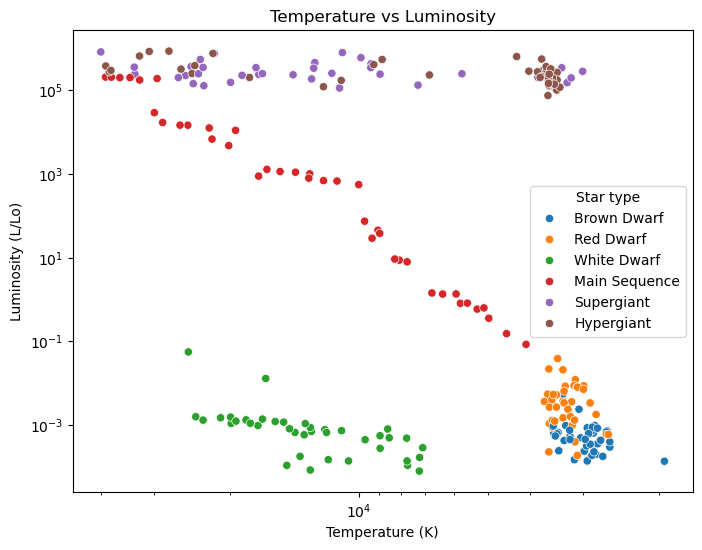

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=df_stars['Star type'].map(dict(enumerate(class_names)))
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.title('Temperature vs Luminosity')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()

In [37]:
from sklearn.decomposition import PCA
import numpy as np

x = df_stars.drop(columns=['Star type', 'Star color', 'Spectral Class'])

# Standardize the data manually
#x = x - x.mean()
#x = np.log1p(x - x.min())
#x = x / x.std()

n_components = len(x.columns)

pca = PCA(n_components, svd_solver='full')
pca.fit(x)

eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [3.22101609e+10 7.70991686e+07 1.86840113e+05 4.33537075e+01]
Eigenvectors:
 [[ 2.09892192e-02  9.99778551e-01  1.51672530e-03 -4.06568779e-05]
 [ 9.99737574e-01 -2.09743948e-02 -9.20988063e-03 -1.91786135e-04]
 [ 9.17423519e-03 -1.70987026e-03  9.99925666e-01 -7.84678203e-03]
 [ 2.64585536e-04  2.32090121e-05  7.84473575e-03  9.99969194e-01]]


PCA-transformed data shape: (240, 4)


/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


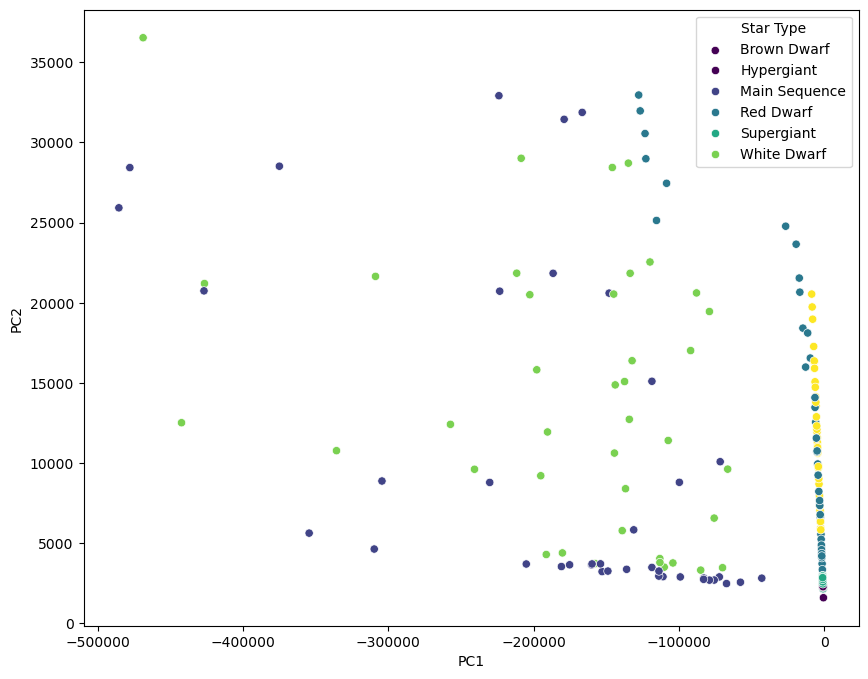

In [40]:
x_pca = pca.transform(x)
print("PCA-transformed data shape:", x_pca.shape)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=df_stars['Star type'], palette='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Star Type', labels=class_names)
plt.show()

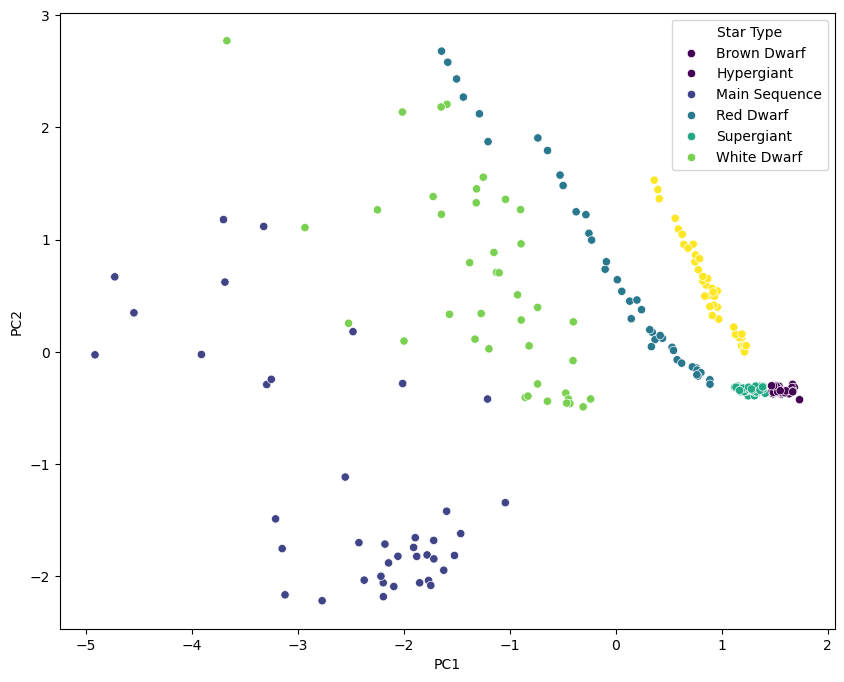

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(x)

pca.fit(X)
X_pca = pca.transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x = X_pca[:, 0], y = X_pca[:, 1], palette= 'viridis', hue=df_stars['Star type'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Star Type', labels=class_names)
plt.show()

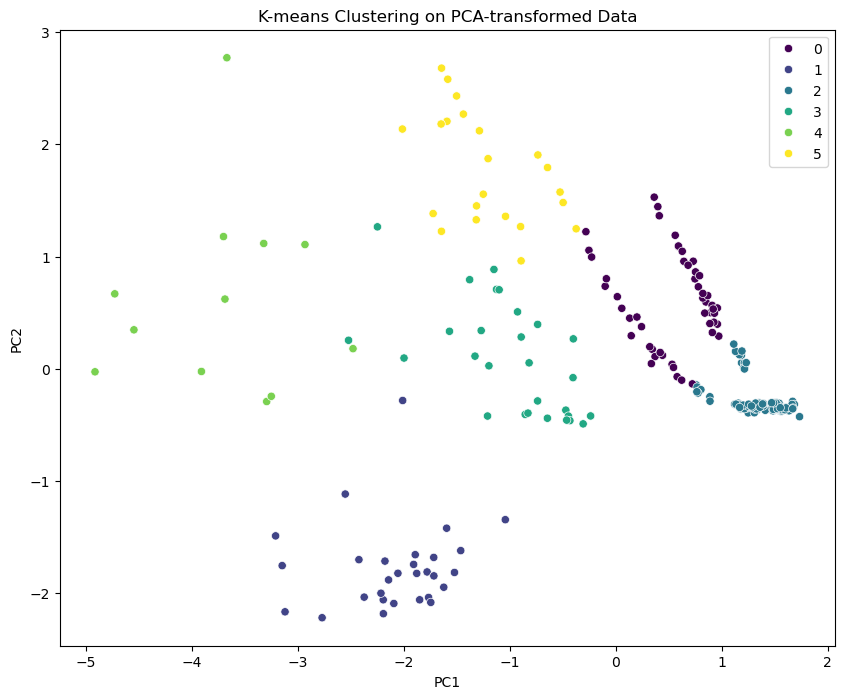

In [43]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering on PCA-transformed Data')
plt.show()